## AMES HOUSING DATASET ##

El siguiente dataset esta pensado para realizar modelos de regresion

79 variables explicativas 
El objetivo y target es el precio de venta

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carga de datos
dataset = pd.read_csv('train.csv')
dataset.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,534,531363010,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500
3,460,528180130,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,248500
4,487,528290030,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,167000


C:\Users\aaran\AppData\Local\Temp\ipykernel_12692\1137045867.py:7: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


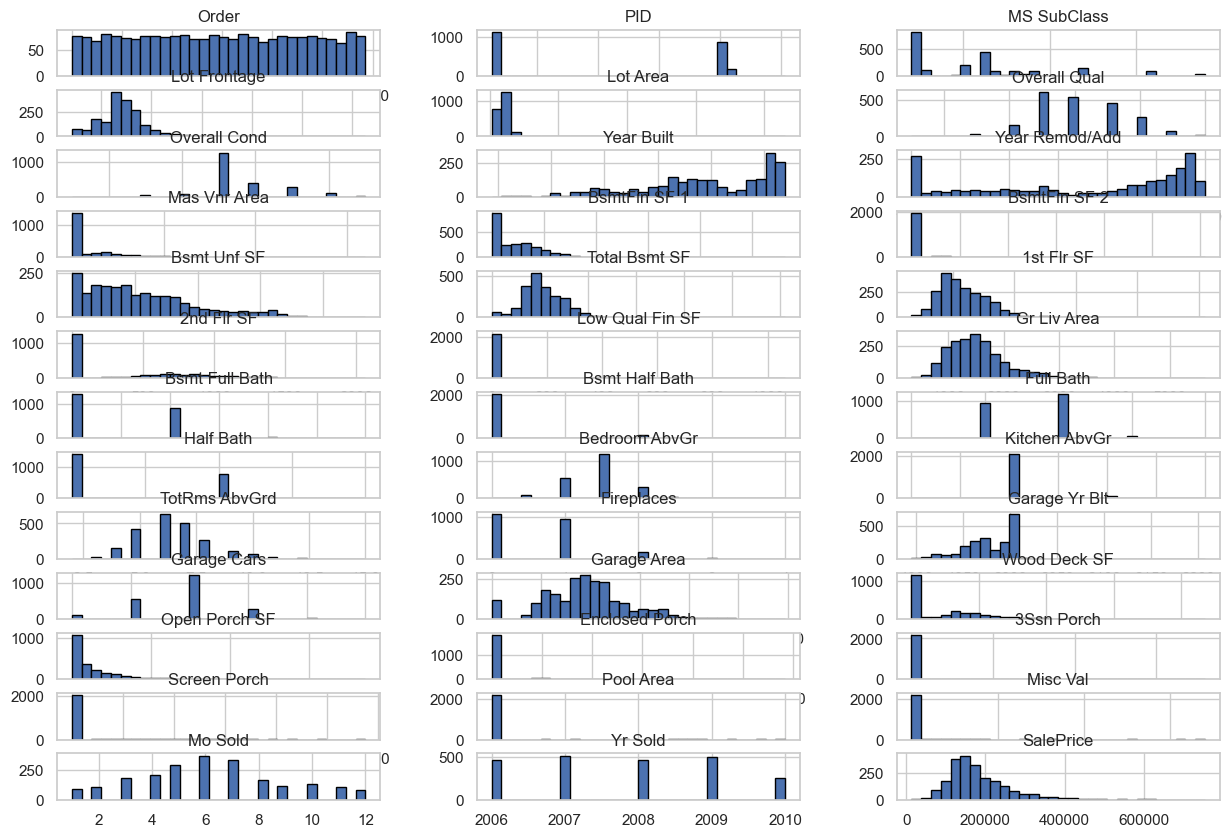

In [3]:
# Configuración de estilo
sns.set_theme(style="whitegrid")

# Supongamos que tu dataframe se llama 'df'
# Creamos una cuadrícula de histogramas para todas las columnas numéricas
dataset.hist(bins=30, figsize=(15, 10), layout=(-1, 3), edgecolor='black')
plt.tight_layout()
plt.show()

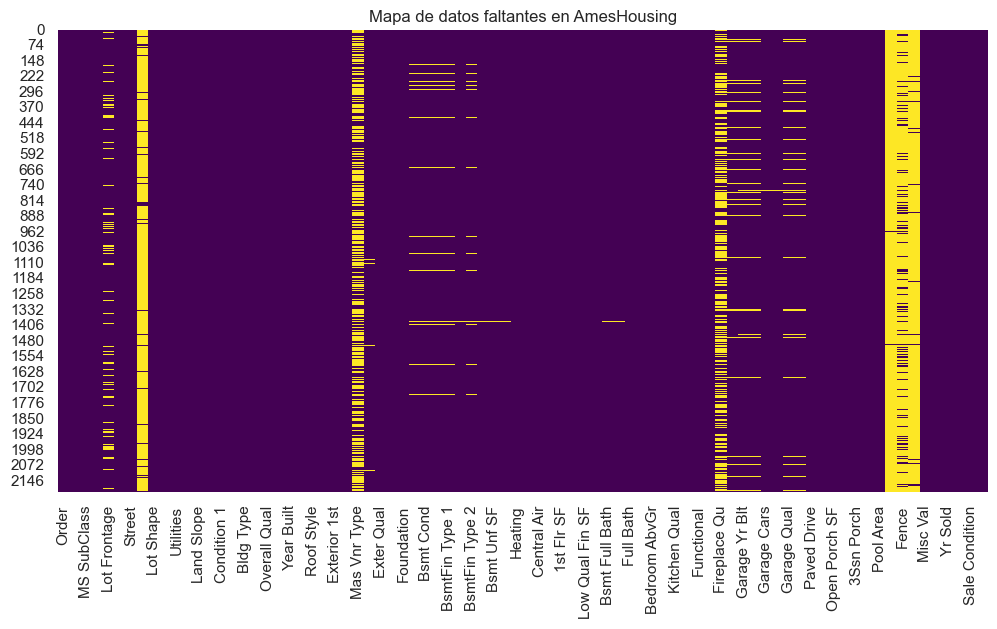

In [4]:
plt.figure(figsize=(12,6))
sns.heatmap(dataset.isnull(), cbar=False, cmap="viridis")

plt.title("Mapa de datos faltantes en AmesHousing")
plt.show()

In [5]:
print("Tamaño original:", dataset.shape)

# Eliminar filas con cualquier valor faltante
df_drop = dataset.dropna()

print("Tamaño después de dropna:", df_drop.shape)

# Comparar reducción
print("Filas eliminadas:", dataset.shape[0] - df_drop.shape[0])

Tamaño original: (2197, 82)
Tamaño después de dropna: (0, 82)
Filas eliminadas: 2197


In [6]:
dataset_fixed = dataset.copy()

In [7]:
#Estas columnas tienen una gran cantidad de valores faltantes, solo mostre una columna con estos datos eliminados para luego
#hacer algo con ellos, como eliminar la columna o rellenar los valores faltantes con una estrategia adecuada.
dataset_fixed = dataset_fixed.drop("Alley", axis=1)
dataset_fixed = dataset_fixed.drop("Pool QC", axis=1)
dataset_fixed = dataset_fixed.drop("Fence", axis=1)
dataset_fixed = dataset_fixed.drop("Misc Feature", axis=1)

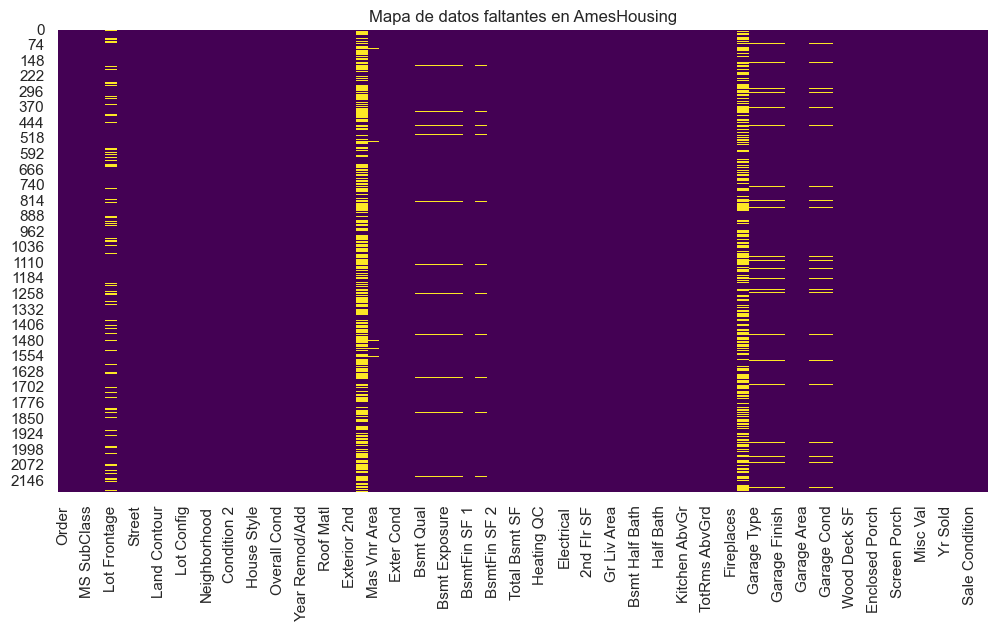

In [8]:
plt.figure(figsize=(12,6))
sns.heatmap(dataset_fixed.isnull(), cbar=False, cmap="viridis")

plt.title("Mapa de datos faltantes en AmesHousing")
plt.show()

In [9]:
# Conteo de valores faltantes por columna
faltantes = dataset.isna().sum()
print(faltantes[faltantes > 0])

Lot Frontage       362
Alley             2054
Mas Vnr Type      1329
Mas Vnr Area        22
Bsmt Qual           67
Bsmt Cond           67
Bsmt Exposure       69
BsmtFin Type 1      67
BsmtFin SF 1         1
BsmtFin Type 2      68
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       1
Bsmt Half Bath       1
Fireplace Qu      1066
Garage Type        120
Garage Yr Blt      122
Garage Finish      122
Garage Cars          1
Garage Area          1
Garage Qual        122
Garage Cond        122
Pool QC           2185
Fence             1778
Misc Feature      2117
dtype: int64


In [10]:
categorical_cols = dataset.select_dtypes(include=["object"]).columns
numeric_cols = dataset.select_dtypes(include=["int64","float64"]).columns

print("Categóricas:", len(categorical_cols))
print("Numéricas:", len(numeric_cols))

Categóricas: 43
Numéricas: 39


C:\Users\aaran\AppData\Local\Temp\ipykernel_12692\2302949936.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = dataset.select_dtypes(include=["object"]).columns


In [11]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

dataset[numeric_cols] = num_imputer.fit_transform(dataset[numeric_cols])
dataset[categorical_cols] = cat_imputer.fit_transform(dataset[categorical_cols])

In [12]:
from sklearn.preprocessing import OneHotEncoder

# En scikit-learn >= 1.2
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded = encoder.fit_transform(dataset[categorical_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=dataset.index
)

dataset_final = pd.concat([dataset[numeric_cols], encoded_df, dataset["SalePrice"]], axis=1)

In [13]:
dataset_final.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial,SalePrice
0,534.0,531363010.0,20.0,80.0,9605.0,7.0,6.0,2007.0,2007.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,159000.0
1,803.0,906203120.0,20.0,90.0,14684.0,7.0,7.0,1990.0,1991.0,234.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,271900.0
2,956.0,916176030.0,20.0,69.0,14375.0,6.0,6.0,1958.0,1958.0,541.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,137500.0
3,460.0,528180130.0,120.0,48.0,6472.0,9.0,5.0,2008.0,2008.0,500.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,248500.0
4,487.0,528290030.0,80.0,61.0,9734.0,7.0,5.0,2004.0,2004.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,167000.0


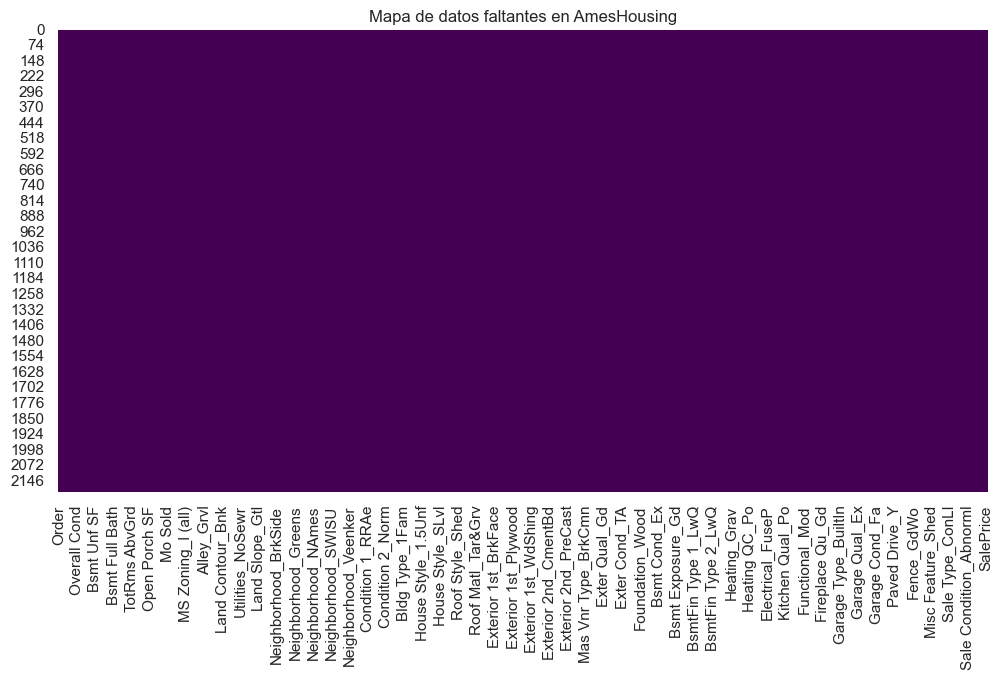

In [14]:
plt.figure(figsize=(12,6))
sns.heatmap(dataset_final.isnull(), cbar=False, cmap="viridis")

plt.title("Mapa de datos faltantes en AmesHousing")
plt.show()


## Entrenamiento ##

In [23]:
import os
import numpy as np
from matplotlib import pyplot

In [ ]:
x = dataset_final.drop('SalePrice', axis=1)
y = dataset_final['SalePrice']
print(x, y)

x2 = np.array(x)
y2 = np.array(y)
print(x2, y2)

m = y2.size

       Order          PID  MS SubClass  Lot Frontage  Lot Area  Overall Qual  \
0      534.0  531363010.0         20.0          80.0    9605.0           7.0   
1      803.0  906203120.0         20.0          90.0   14684.0           7.0   
2      956.0  916176030.0         20.0          69.0   14375.0           6.0   
3      460.0  528180130.0        120.0          48.0    6472.0           9.0   
4      487.0  528290030.0         80.0          61.0    9734.0           7.0   
...      ...          ...          ...           ...       ...           ...   
2192  2764.0  906420020.0         60.0          80.0   10041.0           8.0   
2193   906.0  909129090.0         50.0          70.0    6300.0           5.0   
2194  1097.0  528292060.0         60.0          41.0   12460.0           7.0   
2195   236.0  905426060.0         30.0          85.0   10625.0           5.0   
2196  1062.0  528142020.0         60.0          74.0    8899.0           8.0   

      Overall Cond  Year Built  Year Re

In [28]:
print(m)

4394


In [21]:
print(x2)

[[5.3400000e+02 5.3136301e+08 2.0000000e+01 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]
 [8.0300000e+02 9.0620312e+08 2.0000000e+01 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]
 [9.5600000e+02 9.1617603e+08 2.0000000e+01 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 ...
 [1.0970000e+03 5.2829206e+08 6.0000000e+01 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]
 [2.3600000e+02 9.0542606e+08 3.0000000e+01 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 [1.0620000e+03 5.2814202e+08 6.0000000e+01 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]]


In [19]:
print(x)

       Order          PID  MS SubClass  Lot Frontage  Lot Area  Overall Qual  \
0      534.0  531363010.0         20.0          80.0    9605.0           7.0   
1      803.0  906203120.0         20.0          90.0   14684.0           7.0   
2      956.0  916176030.0         20.0          69.0   14375.0           6.0   
3      460.0  528180130.0        120.0          48.0    6472.0           9.0   
4      487.0  528290030.0         80.0          61.0    9734.0           7.0   
...      ...          ...          ...           ...       ...           ...   
2192  2764.0  906420020.0         60.0          80.0   10041.0           8.0   
2193   906.0  909129090.0         50.0          70.0    6300.0           5.0   
2194  1097.0  528292060.0         60.0          41.0   12460.0           7.0   
2195   236.0  905426060.0         30.0          85.0   10625.0           5.0   
2196  1062.0  528142020.0         60.0          74.0    8899.0           8.0   

      Overall Cond  Year Built  Year Re

In [16]:
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [22]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = normalizarCaracteristicas(x2)

print(x2)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[5.3400000e+02 5.3136301e+08 2.0000000e+01 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]
 [8.0300000e+02 9.0620312e+08 2.0000000e+01 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]
 [9.5600000e+02 9.1617603e+08 2.0000000e+01 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 ...
 [1.0970000e+03 5.2829206e+08 6.0000000e+01 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]
 [2.3600000e+02 9.0542606e+08 3.0000000e+01 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 [1.0620000e+03 5.2814202e+08 6.0000000e+01 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]]
Media calculada: [1.46051252e+03 7.12787220e+08 5.70641784e+01 6.94588075e+01
 1.02680701e+04 6.11652253e+00 5.55257169e+00 1.97203095e+03
 1.98478107e+03 1.04049158e+02 4.45467000e+02 4.93195266e+01
 5.67132226e+02 1.06199203e+03 1.17174465e+03 3.31932180e+02
 4.19663177e+00 1.50787346e+03 4.25580337e-01 6.32680929e-02
 1.59262631e+00 3.69594902e-01 2.85889850e+00 1.04915794e+00
 6.47064178e+00 5.98998635e-01 1.97900728e+03 1.78197

In [24]:
def graficarDatos(x, y, xlabel, ylabel):
  fig = pyplot.figure()
  pyplot.plot(x, y, 'ro')
  pyplot.xlabel(xlabel)
  pyplot.ylabel(ylabel)

In [27]:
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 4394 and the array at index 1 has size 2197

In [29]:
def calcularCosto(X, y, theta):
  m = y.size
  J = 0
  # h = np.dot(X, theta)
  # print(h)
  J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
  return J

In [ ]:
theta=np.array([0.1, 5.0, 0.1])
JJ = calcularCosto(X_ready, y, theta)
print(f"con theta:{ theta } se obtiene un costo de: {JJ}")

## Usando redes neuronales ##

In [30]:
import torch

In [47]:
D_in, H, D_out = 784, 100, 10

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
)

In [48]:
outputs = model(torch.randn(600, 784))
outputs.shape

torch.Size([600, 10])

In [43]:
x2.__len__

<method-wrapper '__len__' of numpy.ndarray object at 0x000002057C247F30>

In [50]:
# normalización y split

X_train =x2[:60000] / 255.
X_test =x2[60000:] / 255.
y_train = y2[:60000].astype(np.int32)
y_test = y2[60000:].astype(np.int32)

In [51]:
# función de pérdida y derivada

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def cross_entropy(output, target):
    logits = output[torch.arange(len(output)), target]
    loss = - logits + torch.log(torch.sum(torch.exp(output), axis=-1))
    loss = loss.mean()
    return loss

In [52]:
# convertimos datos a tensores y copiamos en gpu

X_t = torch.from_numpy(X_train).float()
Y_t = torch.from_numpy(y_train).long()

# bucle entrenamiento
epochs = 350
lr = 0.8
log_each = 10
l = []
for e in range(1, epochs + 1):

    # forward
    y_pred = model(X_t)

    # loss
    loss = cross_entropy(y_pred, Y_t)
    l.append(loss.item())

    # ponemos a cero los gradientes
    model.zero_grad()

    # Backprop (calculamos todos los gradientes automáticamente)
    loss.backward()

    # update de los pesos
    with torch.no_grad():
        for param in model.parameters():
            param -= lr * param.grad

    if not e % log_each:
        print(f"Epoch {e}/{epochs} Loss {np.mean(l):.5f}")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (2197x305 and 784x100)